#### Librerias

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from scipy import sparse
import joblib
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


#### Variables

In [2]:
MODELOS_PATH = "/content/drive/MyDrive/Trabajo práctico 3/modelos"

#### Carga de datos y modelos

In [3]:
df_train = pd.read_pickle(f"{MODELOS_PATH}/train_limpio.pkl")
df_test = pd.read_pickle(f"{MODELOS_PATH}/test_con_textblob.pkl")

X_train_bow = sparse.load_npz(f"{MODELOS_PATH}/X_train_bow.npz")
X_train_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_train_tfidf.npz")
X_val_bow = sparse.load_npz(f"{MODELOS_PATH}/X_val_bow.npz")
X_val_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_val_tfidf.npz")
X_test_bow = sparse.load_npz(f"{MODELOS_PATH}/X_test_bow.npz")
X_test_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_test_tfidf.npz")

y_train = np.load(f"{MODELOS_PATH}/y_train.npy")
y_val = np.load(f"{MODELOS_PATH}/y_val.npy")

modelo_nb = joblib.load(f"{MODELOS_PATH}/modelo_nb_optimizado.pkl")
modelo_lr = joblib.load(f"{MODELOS_PATH}/modelo_lr_optimizado.pkl")

#### Subset binario y predicciones de los 3 métodos

In [4]:
mask_binario = df_test["polarity"].values != 2

X_test_bow_bin = X_test_bow[mask_binario]
X_test_tfidf_bin = X_test_tfidf[mask_binario]
y_test_bin = df_test["polarity"].values[mask_binario]
df_test_bin = df_test[mask_binario].reset_index(drop=True)

pred_nb_bin = modelo_nb.predict(X_test_bow_bin)
pred_lr_bin = modelo_lr.predict(X_test_tfidf_bin)
pred_textblob_bin = df_test_bin["pred_textblob"].values

#### Métrica principal del proyecto: NB vs LR sobre validación (240k)

In [5]:
pred_nb_val = modelo_nb.predict(X_val_bow)
pred_lr_val = modelo_lr.predict(X_val_tfidf)

print("=== NAIVE BAYES — Validación ===")
print(classification_report(y_val, pred_nb_val, target_names=["Negativo", "Positivo"]))

print("=== LOGISTIC REGRESSION — Validación ===")
print(classification_report(y_val, pred_lr_val, target_names=["Negativo", "Positivo"]))

=== NAIVE BAYES — Validación ===
              precision    recall  f1-score   support

    Negativo       0.77      0.78      0.77    120000
    Positivo       0.77      0.76      0.77    120000

    accuracy                           0.77    240000
   macro avg       0.77      0.77      0.77    240000
weighted avg       0.77      0.77      0.77    240000

=== LOGISTIC REGRESSION — Validación ===
              precision    recall  f1-score   support

    Negativo       0.79      0.76      0.78    120000
    Positivo       0.77      0.80      0.79    120000

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000



Esta es la comparación que importa: mismo conjunto grande (240k) para los dos
modelos. LR queda apenas arriba de NB acá — al revés de lo que se ve más abajo
contra el test manual. Es la prueba concreta de por qué la validación es la
métrica principal del proyecto: con 359 tweets, quién "gana" puede cambiar solo
por el ruido de la muestra; con 240k, el resultado es mucho más estable.

#### Comparación secundaria: NB, LR y TextBlob sobre el test manual (359)

In [7]:
print("=== NAIVE BAYES — Test manual ===")
print(classification_report(y_test_bin, pred_nb_bin, target_names=["Negativo", "Positivo"]))

print("=== LOGISTIC REGRESSION — Test manual ===")
print(classification_report(y_test_bin, pred_lr_bin, target_names=["Negativo", "Positivo"]))

print("=== TEXTBLOB — Test manual ===")
print(classification_report(y_test_bin, pred_textblob_bin, labels=[0, 4], target_names=["Negativo", "Positivo"]))

=== NAIVE BAYES — Test manual ===
              precision    recall  f1-score   support

    Negativo       0.80      0.83      0.82       177
    Positivo       0.83      0.80      0.82       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
weighted avg       0.82      0.82      0.82       359

=== LOGISTIC REGRESSION — Test manual ===
              precision    recall  f1-score   support

    Negativo       0.80      0.81      0.81       177
    Positivo       0.81      0.81      0.81       182

    accuracy                           0.81       359
   macro avg       0.81      0.81      0.81       359
weighted avg       0.81      0.81      0.81       359

=== TEXTBLOB — Test manual ===
              precision    recall  f1-score   support

    Negativo       0.86      0.49      0.62       177
    Positivo       0.73      0.79      0.76       182

   micro avg       0.77      0.64      0.70       359
   macro avg       0.

Esta comparación es la única forma de incluir a TextBlob (no se puede medir contra
la validación, porque no tiene etiquetas propias — solo predice). Sirve para lo que
sirve: comparar contra el pre-entrenado en igualdad de condiciones. No es la que
define "cuál modelo es mejor" entre NB y LR — para eso está la de arriba.

#### TextBlob y la "zona gris": cuántos tweets binarios predijo como neutral

In [8]:
n_hedged = (pred_textblob_bin == 2).sum()
pct_hedged = n_hedged / len(pred_textblob_bin) * 100

print(f"TextBlob predijo 'neutral' en {n_hedged} de {len(pred_textblob_bin)} tweets con etiqueta real binaria ({pct_hedged:.1f}%)")

TextBlob predijo 'neutral' en 61 de 359 tweets con etiqueta real binaria (17.0%)


Acá está la causa del bajo accuracy de TextBlob: en un ~17% de tweets que en
realidad eran positivos o negativos, prefirió no definirse. Cada duda cuenta como
error en la evaluación binaria. TextBlob puede dudar; NB y LR no tienen esa opción.

Las matrices completas muestran el patrón de comportamiento que distingue a los
dos modelos: LR recupera más positivos reales que NB en train (menos falsos
negativos: 154 mil vs 188 mil), pero a costa de más falsos positivos (187 mil vs
174 mil). En test se mantiene la tendencia: LR comete más falsos positivos (34 vs
29). NB es más conservador, LR más "generoso" prediciendo positivo — ninguno es
objetivamente mejor, es un trade-off que depende de qué error resulte más costoso
según el uso.

#### Evaluación completa: train, validación y test

In [9]:
pred_nb_train = modelo_nb.predict(X_train_bow)
pred_lr_train = modelo_lr.predict(X_train_tfidf)

print("=== NAIVE BAYES ===")
print("--- Train ---")
print(classification_report(y_train, pred_nb_train, target_names=["Negativo", "Positivo"]))
print("--- Validación ---")
print(classification_report(y_val, pred_nb_val, target_names=["Negativo", "Positivo"]))
print("--- Test manual ---")
print(classification_report(y_test_bin, pred_nb_bin, target_names=["Negativo", "Positivo"]))

print("\n=== LOGISTIC REGRESSION ===")
print("--- Train ---")
print(classification_report(y_train, pred_lr_train, target_names=["Negativo", "Positivo"]))
print("--- Validación ---")
print(classification_report(y_val, pred_lr_val, target_names=["Negativo", "Positivo"]))
print("--- Test manual ---")
print(classification_report(y_test_bin, pred_lr_bin, target_names=["Negativo", "Positivo"]))

=== NAIVE BAYES ===
--- Train ---
              precision    recall  f1-score   support

    Negativo       0.77      0.78      0.78    680000
    Positivo       0.78      0.76      0.77    680000

    accuracy                           0.77   1360000
   macro avg       0.77      0.77      0.77   1360000
weighted avg       0.77      0.77      0.77   1360000

--- Validación ---
              precision    recall  f1-score   support

    Negativo       0.77      0.78      0.77    120000
    Positivo       0.77      0.76      0.77    120000

    accuracy                           0.77    240000
   macro avg       0.77      0.77      0.77    240000
weighted avg       0.77      0.77      0.77    240000

--- Test manual ---
              precision    recall  f1-score   support

    Negativo       0.80      0.83      0.82       177
    Positivo       0.83      0.80      0.82       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
w

Train y validación deberían dar parecidos entre sí (mismo origen de etiquetas,
automático por emoticono) — si es así, confirma que no hay overfitting. El test
manual es el que se despega, por venir de un etiquetado distinto (a mano).

#### Matrices de confusión — train, validación y test

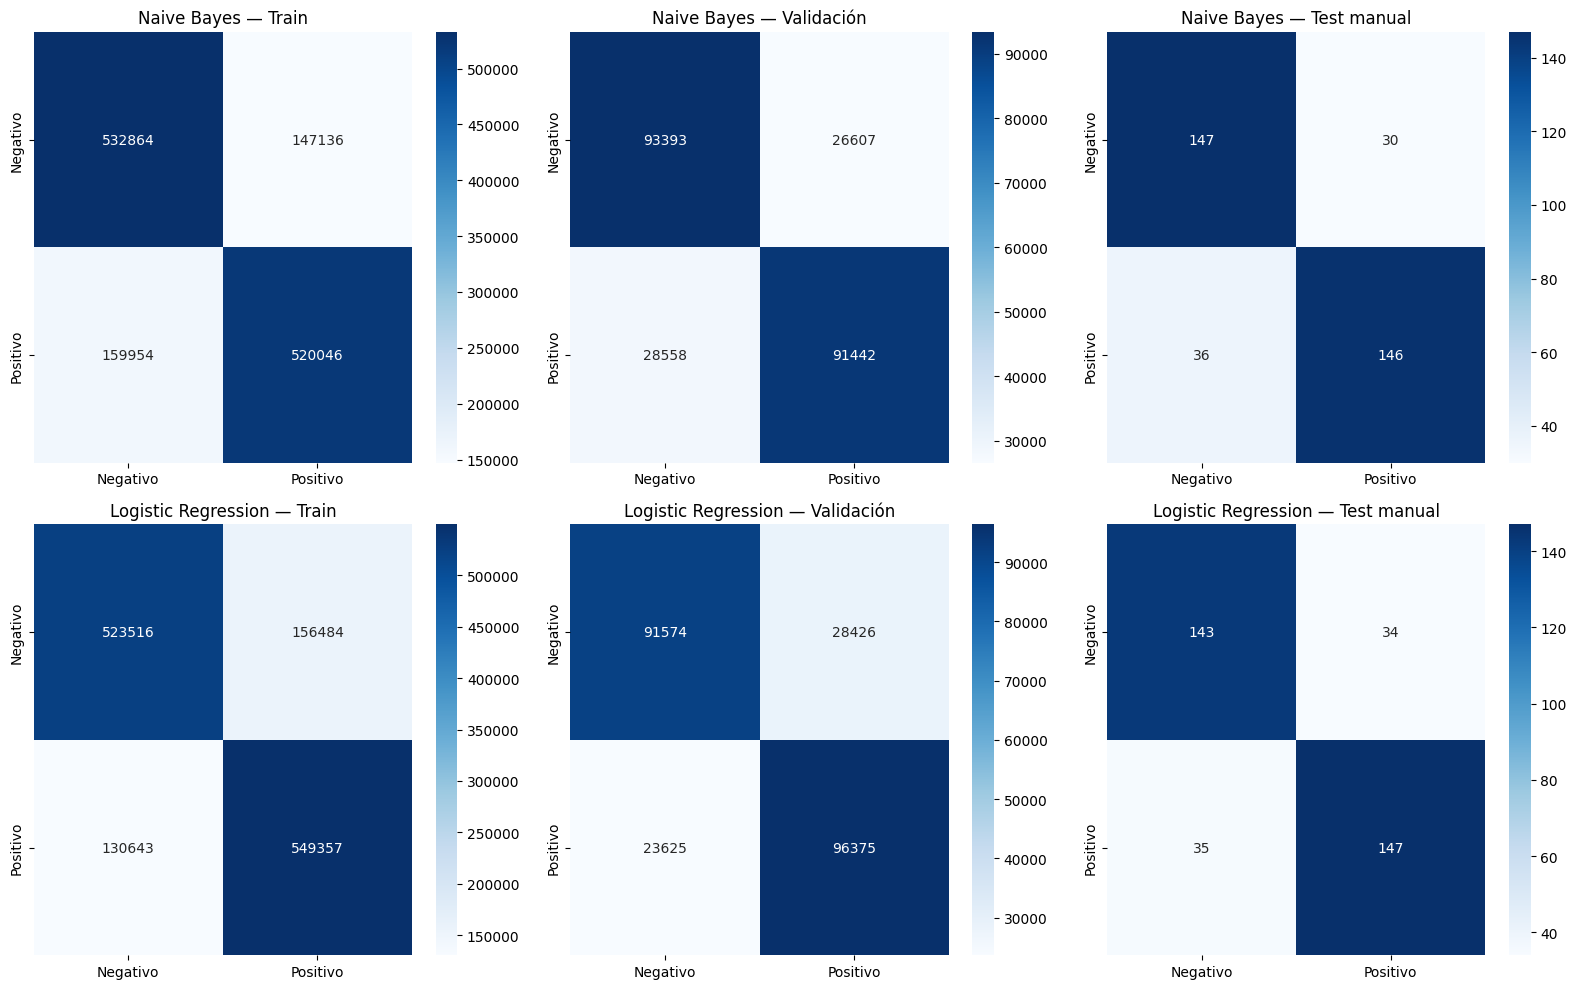

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

conjuntos_nb = [(y_train, pred_nb_train, "Train"), (y_val, pred_nb_val, "Validación"), (y_test_bin, pred_nb_bin, "Test manual")]
conjuntos_lr = [(y_train, pred_lr_train, "Train"), (y_val, pred_lr_val, "Validación"), (y_test_bin, pred_lr_bin, "Test manual")]

for i, (y_true, y_pred, nombre) in enumerate(conjuntos_nb):
    cm = confusion_matrix(y_true, y_pred, labels=[0,4])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0,i],
                xticklabels=["Negativo","Positivo"], yticklabels=["Negativo","Positivo"])
    axes[0,i].set_title(f"Naive Bayes — {nombre}")

for i, (y_true, y_pred, nombre) in enumerate(conjuntos_lr):
    cm = confusion_matrix(y_true, y_pred, labels=[0,4])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1,i],
                xticklabels=["Negativo","Positivo"], yticklabels=["Negativo","Positivo"])
    axes[1,i].set_title(f"Logistic Regression — {nombre}")

plt.tight_layout()
plt.show()

El patrón se confirma con números exactos y se sostiene en train y validación por
igual: Naive Bayes comete más falsos negativos que falsos positivos (es cauteloso,
tiende a subestimar lo positivo), mientras que Logistic Regression comete más
falsos positivos que falsos negativos (es generoso, tiende a sobreestimarlo). No es
ruido de una muestra puntual — se repite de forma consistente en 1.36M y en 240k de
datos. Ninguno es objetivamente mejor: es un trade-off que depende de qué error sea
más costoso según el uso que se le dé al modelo.

#### ROC-AUC (sobre validación — la muestra grande y confiable)

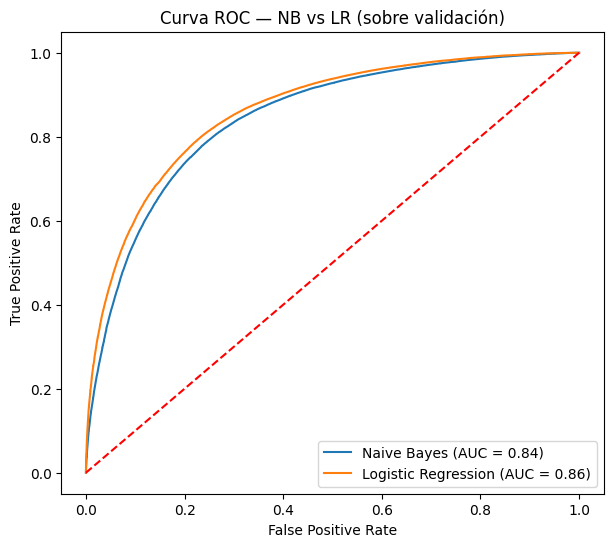

In [11]:
proba_nb = modelo_nb.predict_proba(X_val_bow)[:, 1]
proba_lr = modelo_lr.predict_proba(X_val_tfidf)[:, 1]

roc_nb = roc_auc_score(y_val, proba_nb)
roc_lr = roc_auc_score(y_val, proba_lr)

fpr_nb, tpr_nb, _ = roc_curve(y_val, proba_nb, pos_label=4)
fpr_lr, tpr_lr, _ = roc_curve(y_val, proba_lr, pos_label=4)

plt.figure(figsize=(7,6))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {roc_nb:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_lr:.2f})")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — NB vs LR (sobre validación)")
plt.legend(loc="lower right")
plt.show()

Con el AUC calculado sobre validación (240k) en vez del test chico, el resultado
es más confiable — y esta vez LR gana en las dos métricas (accuracy y AUC), no
solo en una. Antes, con el test manual de 359 tweets, el AUC daba empatado (0.90
ambos) y NB ganaba apenas en accuracy; ese resultado era menos sólido por el
tamaño de la muestra. Con 240k de datos, la ventaja de LR queda clara y
consistente en ambas métricas.

#### Similitud coseno — vecino más cercano de tweets mal clasificados (métrica obligatoria)

In [12]:
mask_error_lr = pred_lr_bin != y_test_bin
indices_error = df_test_bin[mask_error_lr].index[:3]

for idx in indices_error:
    vector_tweet = X_test_tfidf_bin[idx]
    similitudes = X_train_tfidf.dot(vector_tweet.T).toarray().flatten()
    idx_vecino = similitudes.argmax()

    print("Tweet mal clasificado:", df_test_bin.loc[idx, "text"])
    print("  Real:", df_test_bin.loc[idx, "polarity"], "| Predicho LR:", pred_lr_bin[idx])
    print(f"Vecino más cercano en training (similitud coseno = {similitudes[idx_vecino]:.3f}):")
    print(" ", df_train.iloc[idx_vecino]["text"], "| polaridad:", df_train.iloc[idx_vecino]["polarity"])
    print("-" * 80)

Tweet mal clasificado: @kenburbary You'll love your Kindle2. I've had mine for a few months and never looked back. The new big one is huge! No need for remorse! :)
  Real: 4 | Predicho LR: 0
Vecino más cercano en training (similitud coseno = 0.414):
  I think the kindle DX is worse than the Kindle 2.  I love my Kindle 1 though. | polaridad: 0
--------------------------------------------------------------------------------
Tweet mal clasificado: #lebron best athlete of our generation, if not all time (basketball related) I don't want to get into inter-sport debates about   __1/2
  Real: 4 | Predicho LR: 0
Vecino más cercano en training (similitud coseno = 0.416):
  @bibendum_iwa The Appliance Generation ã?§ã?ã?­  | polaridad: 4
--------------------------------------------------------------------------------
Tweet mal clasificado: @Pmillzz lebron IS THE BOSS
  Real: 4 | Predicho LR: 0
Vecino más cercano en training (similitud coseno = 0.750):
  ...no more Lebron  | polaridad: 0
--------

#### Conclusiones

Sobre validación (240k, la métrica principal), LR le gana a NB: accuracy 0.78 vs
0.77, AUC 0.86 vs 0.84. Es distinto a lo que daba el test manual de 359 (NB
arriba, AUC empatado) — con más datos, el resultado es más confiable, y ahí LR
gana claro.

La optimización de hiperparámetros no mejoró nada (mismo accuracy que el
baseline en los dos modelos) — con 1.36M de datos, ajustar alpha o C no tuvo
efecto medible.

No hay overfitting: train y validación dan accuracy muy parecido en los dos
modelos (diferencias menores a un punto porcentual).

Patrón de errores consistente: NB comete más falsos negativos (cauteloso), LR
más falsos positivos (generoso) — se repite igual en train y en validación, no
es ruido de una muestra.

El test manual da mejor accuracy que train/validación en los dos modelos,
probablemente porque sus etiquetas las puso una persona a mano, mientras que
train/validación se etiquetaron automático por emoticono (más ruidoso).

Contra TextBlob (evaluado en el test manual, el único con etiquetas reales):
0.64 de accuracy vs 0.81-0.82 de los modelos propios. No está mal calibrado —
predijo "neutral" en ~17% de tweets binarios, algo que NB/LR no pueden hacer.

Similitud coseno (métrica obligatoria): en 2 de 3 errores de LR analizados,
tweets con negación ("No need for remorse!", "...no more Lebron") pierden el
"not"/"no" al sacar stopwords, y el modelo se queda con palabras sueltas que
apuntan al sentimiento contrario. Se sostuvo igual con una configuración de
entrenamiento distinta — es un problema del preprocesamiento, no de una corrida
puntual.

Limitación central: el training es binario (etiquetado automático por
emoticono, sin neutrales); el test manual sí tiene neutrales. Por eso se evaluó
siempre sobre el subset binario, y TextBlob (que sí puede predecir neutral) se
analizó aparte.